In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

df = pd.read_csv('cleaned_housesales_data.csv')

In [2]:
# Unikal shaharlar soni
num_cities = df['city'].nunique()
print(f"Jami shaharlar soni: {num_cities}")

Jami shaharlar soni: 44


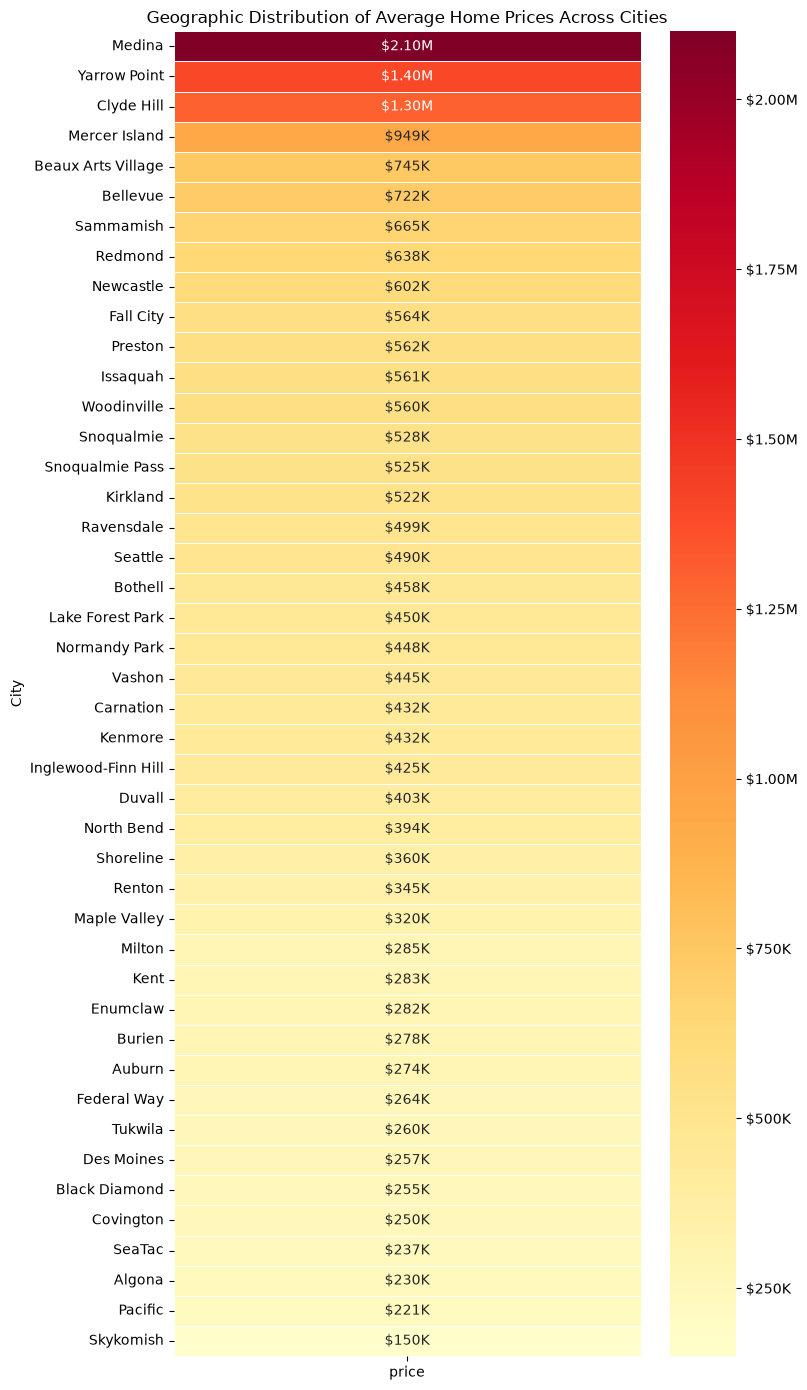

In [3]:
from matplotlib.ticker import FuncFormatter

city_price = (
    df.groupby("city")["price"]
      .median()
      .sort_values(ascending=False)
      .to_frame()
)

def money_fmt(x, pos=None):
    if x >= 1_000_000:
        return f"${x / 1_000_000:.2f}M"
    elif x >= 1_000:
        return f"${x / 1_000:.0f}K"
    return f"${x:,.0f}"

plt.figure(figsize=(8, 14))

ax = sns.heatmap(
    city_price,
    annot=True,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": ""}
)

# Data labels
for text in ax.texts:
    value = float(text.get_text())
    text.set_text(money_fmt(value))

# Colorbar
colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))

plt.title("Geographic Distribution of Average Home Prices Across Cities")
plt.xlabel("")
plt.ylabel("City")
plt.tight_layout()
plt.show()

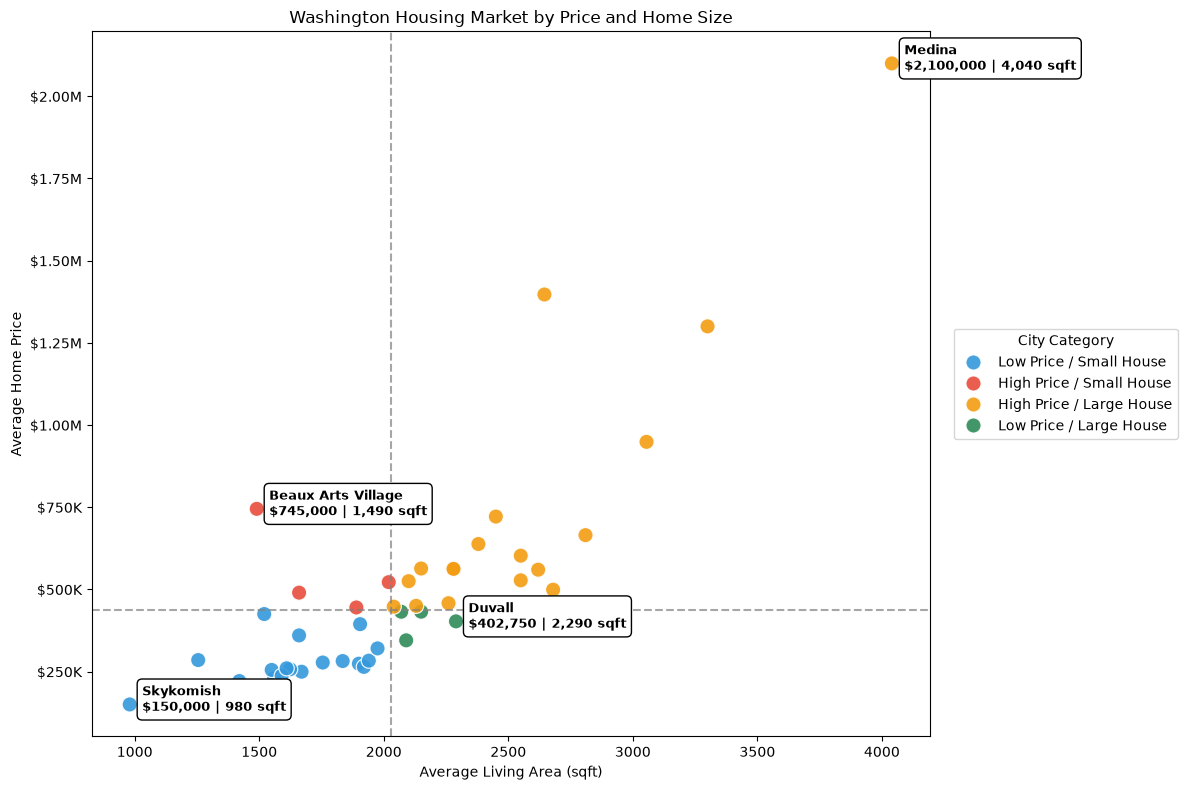

In [7]:
city_profile = (
    df.groupby("city")
      .agg(
          median_price=("price", "median"),
          median_sqft=("sqft_living", "median")
      )
      .reset_index()
)

price_median = city_profile["median_price"].median()
sqft_median = city_profile["median_sqft"].median()

city_profile["category"] = np.select(
    [
        (city_profile["median_price"] >= price_median) &
        (city_profile["median_sqft"] < sqft_median),

        (city_profile["median_price"] >= price_median) &
        (city_profile["median_sqft"] >= sqft_median),

        (city_profile["median_price"] < price_median) &
        (city_profile["median_sqft"] < sqft_median),

        (city_profile["median_price"] < price_median) &
        (city_profile["median_sqft"] >= sqft_median)
    ],
    [
        "High Price / Small House",
        "High Price / Large House",
        "Low Price / Small House",
        "Low Price / Large House"
    ],
    default="Other"
)

colors = {
    "High Price / Small House": "#E74C3C",
    "High Price / Large House": "#F39C12",
    "Low Price / Small House": "#3498DB",
    "Low Price / Large House": "#2E8B57"
}

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=city_profile,
    x="median_sqft",
    y="median_price",
    hue="category",
    palette=colors,
    s=120,
    alpha=0.9
)


label_cities = pd.concat([
    city_profile[city_profile["category"] == "High Price / Small House"]
        .nlargest(1, "median_price"),

    city_profile[city_profile["category"] == "High Price / Large House"]
        .nlargest(1, "median_price"),

    city_profile[city_profile["category"] == "Low Price / Small House"]
        .nsmallest(1, "median_price"),

    city_profile[city_profile["category"] == "Low Price / Large House"]
        .nlargest(1, "median_sqft")
])



for _, row in label_cities.iterrows():
    ax.text(
        row["median_sqft"] + 50,
        row["median_price"] +15000,
        f'{row["city"]}\n'
        f'${row["median_price"]:,.0f} | '
        f'{row["median_sqft"]:,.0f} sqft',
        fontsize=9,
        fontweight="bold",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )


# median reference lines
plt.axvline(sqft_median, color="gray", linestyle="--", alpha=0.7)
plt.axhline(price_median, color="gray", linestyle="--", alpha=0.7)

plt.title("Washington Housing Market by Price and Home Size")
plt.xlabel("Average Living Area (sqft)")
plt.ylabel("Average Home Price")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(money_fmt)
)

plt.legend(
    title="City Category",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

plt.tight_layout()
plt.show()

In [5]:
city_profile["category"].value_counts()

category
Low Price / Small House     18
High Price / Large House    18
High Price / Small House     4
Low Price / Large House      4
Name: count, dtype: int64